In [ ]:
# COHORT ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')

In [4]:
df=pd.read_csv(r'D:\202-2026bootcampproject\Python DataCleaning Output File.csv')

In [5]:
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])
df['Invoice_Date_Only']=pd.to_datetime(df['Invoice_Date_Only'])
df['Week_Beginning']=pd.to_datetime(df['Week_Beginning'])
df['Revenue']=df['Quantity']*df['Price']

In [39]:
Completed=df[df['Order_Status']=='Completed'].copy()
Completed['InvoiceWeek'] = Completed['InvoiceDate'].dt.to_period('W')

In [ ]:
# STEP 2: CALCULATE COHORT INDEX

In [40]:
Completed['Cohort_Week'] = Completed.groupby('Customer ID')['InvoiceWeek'].transform('min')
Completed['Cohort_Index'] = (Completed['InvoiceWeek'] - Completed['Cohort_Week']).apply(lambda x: x.n)

In [36]:
# STEP 3: BUILD TABLES

In [41]:
Cohort_Data = (Completed.groupby(['Cohort_Week', 'Cohort_Index'])['Customer ID'].nunique().reset_index())
Cohort_Table = Cohort_Data.pivot(index='Cohort_Week', columns='Cohort_Index', values='Customer ID')

# Convert cohort table to percentages
Cohort_Size = Cohort_Table.iloc[:, 0]
Retention_Table = Cohort_Table.divide(Cohort_Size, axis=0) * 100

# Convert index to strings for cleaner plotting
Retention_Table.index = Retention_Table.index.astype(str)

In [ ]:
# SECTION 1 — RETENTION HEATMAP

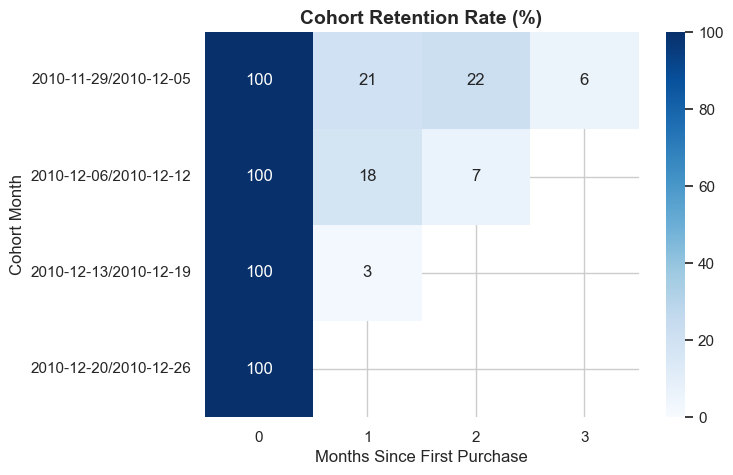

In [43]:
plt.figure(figsize=(7, 5))
sns.heatmap(Retention_Table, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100)

plt.title("Cohort Retention Rate (%)", fontsize=14, fontweight="bold")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")
plt.savefig('Cohort Retention Rate-Weekly.png',bbox_inches='tight')
plt.show()

In [ ]:
# SECTION 2 — COHORT SIZE BAR CHART

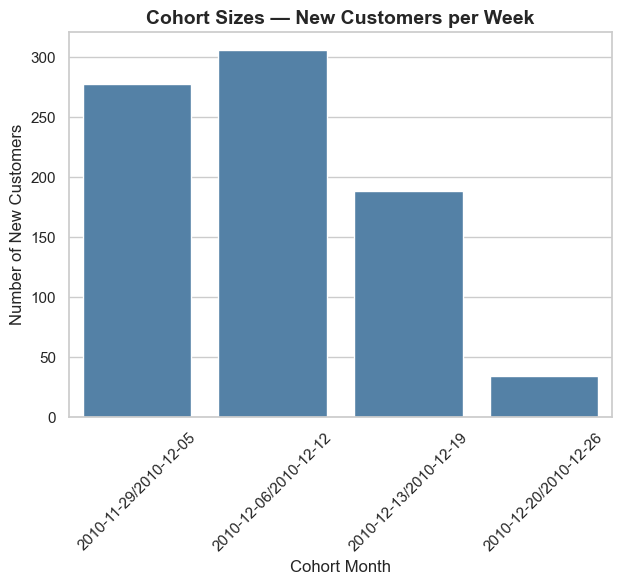

In [44]:
plt.figure(figsize=(7,5))

sns.barplot(x=Cohort_Size.index.astype(str), y=Cohort_Size.values, color="steelblue")

plt.title("Cohort Sizes — New Customers per Week", fontsize=14, fontweight="bold")
plt.xlabel("Cohort Month")
plt.ylabel("Number of New Customers")
plt.xticks(rotation=45)
plt.savefig('New Customers per Week.png',bbox_inches='tight')
plt.show()

In [ ]:
# SECTION 3 — AVERAGE RETENTION CURVE

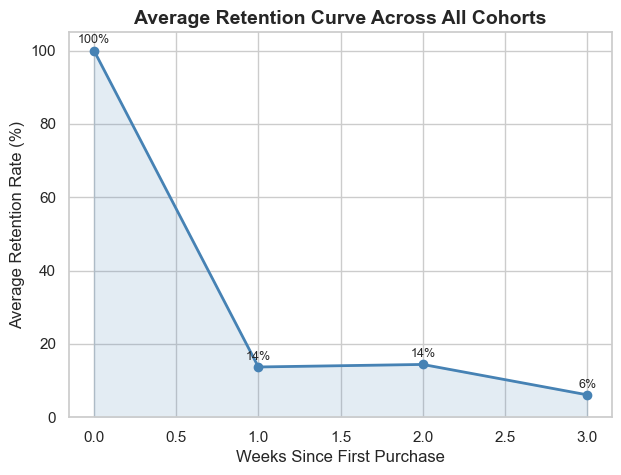

In [47]:
Avg_Retention = Retention_Table.mean(skipna=True)

plt.figure(figsize=(7,5))
plt.plot(Avg_Retention.index, Avg_Retention.values, marker="o", color="steelblue", linewidth=2)
plt.fill_between(Avg_Retention.index, Avg_Retention.values, alpha=0.15, color="steelblue")

plt.title("Average Retention Curve Across All Cohorts", fontsize=14, fontweight="bold")
plt.xlabel("Weeks Since First Purchase")
plt.ylabel("Average Retention Rate (%)")
plt.ylim(0, 105)
plt.savefig('Average Retention Curve Across All Cohorts-Weekly.png',bbox_inches='tight')

for x, y in zip(Avg_Retention.index, Avg_Retention.values):
    plt.text(x, y + 2, f"{y:.0f}%", ha="center", fontsize=9)
    
plt.show()